# Online Investor Attention, Trading Volume, and Stock Returns
## Evidence from Google Trends and WRDS CRSP

## 1. Project Overview

This project examines whether online investor attention is associated with stock trading activity and stock returns.

The analysis focuses on five US stocks:
- NVIDIA (NVDA)
- AMD (AMD)
- Tesla (TSLA)
- JPMorgan Chase (JPM)
- Palantir (PLTR)

The sample period is from January 2023 to December 2024.

## 2. Research Questions

This notebook addresses three research questions:

1. Does higher online investor attention lead to higher monthly trading volume?
2. Does higher online investor attention lead to a significant rise or fall in monthly stock returns?
3. Is the relationship between online investor attention and trading volume stronger than its relationship with monthly returns?

## 3. Intended User / Audience

The notebook is designed for beginner-level finance and business students who want to understand whether online attention can be used as a simple signal for stock market activity.

It may also be useful for entry-level investors who are interested in the difference between trading attention and return predictability.

## 4. Data Sources

This project uses two data sources:

1. Google Trends  
   - Used to measure online investor attention
   - Search terms:
     - NVIDIA stock
     - AMD stock
     - Tesla stock
     - JPM stock
     - Palantir stock

2. WRDS CRSP Daily Stock File  
   - Used to obtain stock price, daily return, and trading volume

## 5. Python Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds
import statsmodels.api as sm

## 6. Google Trends Data Preparation

This section loads the five Google Trends CSV files, standardizes column names, converts dates, and combines them into one monthly attention dataset.

In [2]:
# Load Google Trends CSV files
nvda = pd.read_csv("data/nvda_trends.csv")
amd = pd.read_csv("data/amd_trends.csv")
tsla = pd.read_csv("data/tsla_trends.csv")
jpm = pd.read_csv("data/jpm_trends.csv")
pltr = pd.read_csv("data/pltr_trends.csv")

# Standardize column names and formats
nvda = nvda.rename(columns={nvda.columns[0]: "date", nvda.columns[1]: "attention"})
nvda["date"] = pd.to_datetime(nvda["date"])
nvda["stock"] = "NVDA"
nvda = nvda[["date", "stock", "attention"]]

amd = amd.rename(columns={amd.columns[0]: "date", amd.columns[1]: "attention"})
amd["date"] = pd.to_datetime(amd["date"])
amd["stock"] = "AMD"
amd = amd[["date", "stock", "attention"]]

tsla = tsla.rename(columns={tsla.columns[0]: "date", tsla.columns[1]: "attention"})
tsla["date"] = pd.to_datetime(tsla["date"])
tsla["stock"] = "TSLA"
tsla = tsla[["date", "stock", "attention"]]

jpm = jpm.rename(columns={jpm.columns[0]: "date", jpm.columns[1]: "attention"})
jpm["date"] = pd.to_datetime(jpm["date"])
jpm["stock"] = "JPM"
jpm = jpm[["date", "stock", "attention"]]

pltr = pltr.rename(columns={pltr.columns[0]: "date", pltr.columns[1]: "attention"})
pltr["date"] = pd.to_datetime(pltr["date"])
pltr["stock"] = "PLTR"
pltr = pltr[["date", "stock", "attention"]]

# Combine all stock-level attention data
trends_all = pd.concat([nvda, amd, tsla, jpm, pltr], ignore_index=True)

trends_all.head()
trends_all.info()

# The Google Trends data are successfully transformed into one monthly attention table with three key variables: date, stock, and attention.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       180 non-null    datetime64[ns]
 1   stock      180 non-null    object        
 2   attention  180 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.3+ KB


## 7. WRDS CRSP Data Preparation

This section connects to WRDS, retrieves daily stock data from CRSP, maps PERMNO to ticker symbols, and converts daily data into monthly measures.

In [3]:
# Connect to WRDS
db = wrds.Connection()

Enter your WRDS username [26471]: wenxi_xue
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\26471\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [4]:
# Retrieve CRSP daily data for the five selected stocks
crsp_daily = db.raw_sql("""
    SELECT permno, date, prc, ret, vol
    FROM crsp.dsf
    WHERE permno IN (61241, 47896, 86580, 19788, 93436)
      AND date BETWEEN '2023-01-01' AND '2024-12-31'
    ORDER BY permno, date
""")

# Convert date format
crsp_daily["date"] = pd.to_datetime(crsp_daily["date"])

# Map PERMNO to stock tickers
permno_to_stock = {
    61241: "AMD",
    47896: "JPM",
    86580: "NVDA",
    19788: "PLTR",
    93436: "TSLA"
}
crsp_daily["stock"] = crsp_daily["permno"].map(permno_to_stock)

# Create month label
crsp_daily["month"] = crsp_daily["date"].dt.to_period("M").dt.to_timestamp()

# Aggregate daily data into monthly data
crsp_monthly = (
    crsp_daily
    .groupby(["stock", "month"])
    .agg(
        price=("prc", "last"),
        monthly_volume=("vol", "sum"),
        monthly_return=("ret", lambda x: (1 + x).prod() - 1)
    )
    .reset_index()
)

crsp_monthly = crsp_monthly.rename(columns={"month": "date"})

crsp_monthly.head()
crsp_monthly.info()

# Daily CRSP data are converted into monthly stock-level measures, including month-end price, monthly trading volume, and monthly return.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   stock           120 non-null    object        
 1   date            120 non-null    datetime64[ns]
 2   price           120 non-null    Float64       
 3   monthly_volume  120 non-null    Float64       
 4   monthly_return  120 non-null    Float64       
dtypes: Float64(3), datetime64[ns](1), object(1)
memory usage: 5.2+ KB


## 8. Merge the Two Datasets

The Google Trends monthly attention dataset is merged with the CRSP monthly stock dataset by stock and month.

In [5]:
final_df = pd.merge(
    trends_all,
    crsp_monthly,
    on=["stock", "date"],
    how="inner"
)

final_df.head()
final_df.info()
final_df.isna().sum()

# The merged dataset contains 120 observations and no missing values in the key variables.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            120 non-null    datetime64[ns]
 1   stock           120 non-null    object        
 2   attention       120 non-null    int64         
 3   price           120 non-null    Float64       
 4   monthly_volume  120 non-null    Float64       
 5   monthly_return  120 non-null    Float64       
dtypes: Float64(3), datetime64[ns](1), int64(1), object(1)
memory usage: 6.1+ KB


date              0
stock             0
attention         0
price             0
monthly_volume    0
monthly_return    0
dtype: int64

## 9. Descriptive Analysis

This section provides an initial comparison between high-attention and low-attention months.

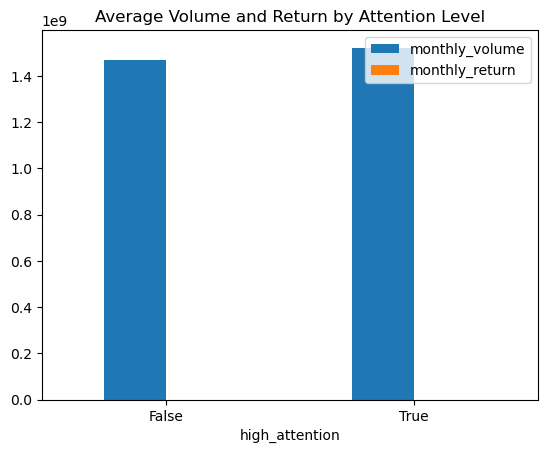

In [6]:
final_df.describe()

# Create a high-attention indicator using the median
final_df["high_attention"] = final_df["attention"] > final_df["attention"].median()

# Compare group means
final_df.groupby("high_attention")[["monthly_volume", "monthly_return"]].mean()

avg_stats = final_df.groupby("high_attention")[["monthly_volume", "monthly_return"]].mean()
avg_stats.plot(kind="bar")
plt.title("Average Volume and Return by Attention Level")
plt.xticks(rotation=0)
plt.show()

### Initial Observation

High-attention months tend to have slightly higher average trading volume.
However, the difference in average monthly returns between high-attention and low-attention months appears small.

## 10. Correlation Analysis

This section examines the linear correlation between online investor attention, monthly trading volume, and monthly return.

In [7]:
final_df[["attention", "monthly_volume", "monthly_return"]].corr()
print(final_df["attention"].corr(final_df["monthly_volume"]))
print(final_df["attention"].corr(final_df["monthly_return"]))

0.23644111422447628
-0.048184188165405914


### Correlation Interpretation
Attention shows a weak positive correlation with monthly trading volume.
By contrast, attention shows almost no correlation with monthly return.

## 11. Regression Analysis

Two simple OLS models are estimated:

1. Monthly trading volume on attention
2. Monthly return on attention

In [8]:
X = final_df["attention"]
X = sm.add_constant(X)

y_volume = final_df["monthly_volume"]
model_volume = sm.OLS(y_volume, X).fit()
print(model_volume.summary())

                            OLS Regression Results                            
Dep. Variable:         monthly_volume   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     6.987
Date:                Sat, 18 Apr 2026   Prob (F-statistic):            0.00932
Time:                        16:32:15   Log-Likelihood:                -2690.6
No. Observations:                 120   AIC:                             5385.
Df Residuals:                     118   BIC:                             5391.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.285e+08   2.46e+08      3.776      0.0

# Interpretation of Model 1
The coefficient on attention is positive and statistically significant.
This suggests that higher online investor attention is associated with higher monthly trading volume.
However, the R-squared is relatively low, which means attention explains only a limited share of the variation in trading volume.

In [9]:
y_return = final_df["monthly_return"]
model_return = sm.OLS(y_return, X).fit()
print(model_return.summary())

                            OLS Regression Results                            
Dep. Variable:         monthly_return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.2746
Date:                Sat, 18 Apr 2026   Prob (F-statistic):              0.601
Time:                        16:32:19   Log-Likelihood:                 44.205
No. Observations:                 120   AIC:                            -84.41
Df Residuals:                     118   BIC:                            -78.83
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0872      0.031      2.802      0.0

# Interpretation of Model 2
The coefficient on attention is negative but not statistically significant.
This suggests that online investor attention does not provide meaningful explanatory power for monthly stock returns in this sample.

## 12. Visualization

Scatter plots are used to visually compare the relationship between attention and monthly trading volume, and between attention and monthly return.

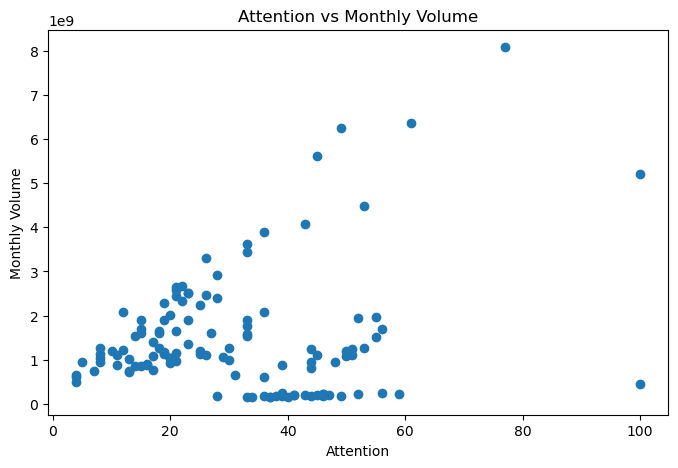

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(final_df["attention"], final_df["monthly_volume"])
plt.title("Attention vs Monthly Volume")
plt.xlabel("Attention")
plt.ylabel("Monthly Volume")
plt.show()

### Visual Interpretation
The scatter plot between attention and monthly volume shows a mild upward tendency, although the relationship is noisy and influenced by several outliers.

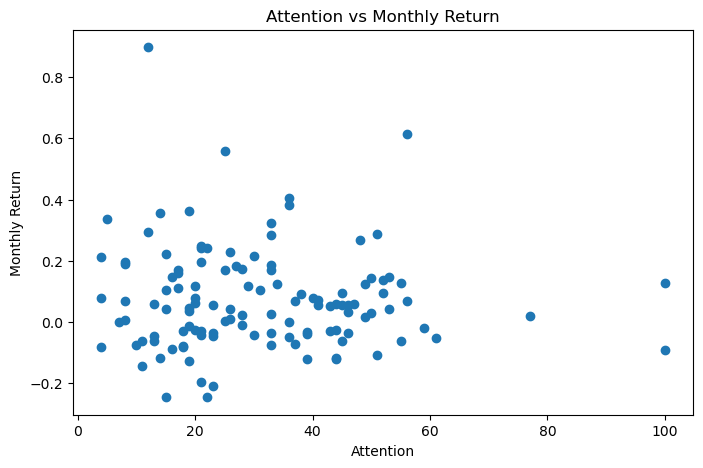

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(final_df["attention"], final_df["monthly_return"])
plt.title("Attention vs Monthly Return")
plt.xlabel("Attention")
plt.ylabel("Monthly Return")
plt.show()

### Visual Interpretation
The second scatter plot shows no clear linear pattern between attention and monthly return.

## 13. Final Findings

This notebook produces three main findings:

1. Online investor attention is positively associated with monthly trading volume.
2. Online investor attention does not show a significant relationship with monthly stock returns.
3. The relationship between attention and trading volume is stronger and clearer than the relationship between attention and monthly returns.

## 14. Limitations

This project has several limitations:

- The sample includes only five stocks, so the results may not generalize to the whole market.
- Google Trends provides relative search interest rather than absolute search volume.
- The analysis is based on association rather than causal identification.
- Some results, especially trading volume, may be influenced by outliers.
- The model is intentionally simple and does not include additional control variables.